### Data Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/home/sameer/Documents/jupyter/ml-projects-portfolio/data/isl_housing.csv').drop_duplicates().dropna()

In [3]:
print(df.dtypes)
print(df.shape)
df.head(5)

Location                  object
Area                      object
Baths                     object
Beds                      object
Dining Room                int64
Laundry Room               int64
Store Rooms                int64
Kitchens                   int64
Drawing Room               int64
Gym                        int64
Powder Room                int64
Steam Room                 int64
No additional rooms        int64
Prayer Rooms               int64
Lounge or Sitting Room     int64
Price                     object
dtype: object
(6263, 16)


,Location,Area,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price
0,"Bahria Town, Lahore, Punjab",10 Marla,-,-,0,0,0,0,0,0,0,0,1,0,0,PKR3.5 Crore
1,"Al Rehman Garden, Lahore, Punjab",4 Marla,4,3,1,1,1,2,1,0,0,0,0,1,0,PKR1.32 Crore
2,"Central Park Housing Scheme, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,0,0,1,0,0,PKR1.74 Crore
3,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,0,0,0,0,0,0,0,0,0,0,0,PKR10.3 Crore
4,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,1,1,2,2,1,0,1,1,0,1,1,PKR8.25 Crore


#### Analysis
###### 5 features are non numeric
- Need to handle Crore - Lakh conversion then change datatype to int
- Need to handle Marla - Kanal conversion then change datatype to int
- Need to isolate Islamabad listings and then onehot encode every location within it
- Baths and Beds are also none numeric, must resolve this
- Should drop several features to make it simpler, maybe combine into one feature "Room"

###### Islamabad only

In [4]:
isl_df = df[df['Location'].str.contains('Islamabad', case=False, na=False)]

###### Fix Baths and Beds features

In [5]:
print(isl_df['Baths'].unique())
print(isl_df['Beds'].unique())

['4' '6' '-' '5' '3' '2' '7' '8' '9' '10' '1']
['3' '5' '6' '7' '2' '-' '4' '8' '9' '10' '11' '1']


Removing '-' rows and fixing datatype

In [6]:
isl_df = isl_df[~isl_df['Baths'].str.contains('-', na=False) & ~isl_df['Beds'].str.contains('-', na=False)]
isl_df['Baths'] = isl_df['Baths'].astype('int')
isl_df['Beds'] = isl_df['Beds'].astype('int')

isl_df.dtypes

Location                  object
Area                      object
Baths                      int64
Beds                       int64
Dining Room                int64
Laundry Room               int64
Store Rooms                int64
Kitchens                   int64
Drawing Room               int64
Gym                        int64
Powder Room                int64
Steam Room                 int64
No additional rooms        int64
Prayer Rooms               int64
Lounge or Sitting Room     int64
Price                     object
dtype: object

###### Cleaning and onehot encoding Islamabad Locations

In [7]:
len(isl_df['Location'].unique())
# 81 is alot of onehot encoding

81

In [8]:
pd.set_option('display.max_rows', None)
print(isl_df.groupby('Location')['Location'].count())
# several very low frequency rows

Location
AGHOSH, Islamabad, Islamabad Capital                                          4
Airport Avenue Housing Society, Islamabad, Islamabad Capital                  1
Ali Pur, Islamabad, Islamabad Capital                                         1
Alipur Farash, Islamabad, Islamabad Capital                                   1
Arsalan Town, Islamabad, Islamabad Capital                                    1
B-17, Islamabad, Islamabad Capital                                           37
Bahria Town, Islamabad, Islamabad Capital                                   196
Bani Gala, Islamabad, Islamabad Capital                                      68
Bhara kahu, Islamabad, Islamabad Capital                                      4
C-18, Islamabad, Islamabad Capital                                            2
CBR Town, Islamabad, Islamabad Capital                                       20
Constitution Avenue, Islamabad, Islamabad Capital                             1
D-12, Islamabad, Islamabad Capi

In [9]:
# drop rows with <=25 rows and update df instead of isl_df
df = isl_df[isl_df.groupby('Location')['Location'].transform('count') >= 25]

In [10]:
print(df.groupby('Location')['Location'].count())
# high frequency rows causing feature imbalance
# Bahria Town,DHA Defence, G-13

Location
B-17, Islamabad, Islamabad Capital            37
Bahria Town, Islamabad, Islamabad Capital    196
Bani Gala, Islamabad, Islamabad Capital       68
D-12, Islamabad, Islamabad Capital            38
DHA Defence, Islamabad, Islamabad Capital    318
E-11, Islamabad, Islamabad Capital            32
E-7, Islamabad, Islamabad Capital             31
F-10, Islamabad, Islamabad Capital            41
F-11, Islamabad, Islamabad Capital            39
F-6, Islamabad, Islamabad Capital             63
F-7, Islamabad, Islamabad Capital             60
F-8, Islamabad, Islamabad Capital             54
G-11, Islamabad, Islamabad Capital            25
G-13, Islamabad, Islamabad Capital           252
G-15, Islamabad, Islamabad Capital            33
G-9, Islamabad, Islamabad Capital             29
I-10, Islamabad, Islamabad Capital            43
I-8, Islamabad, Islamabad Capital             45
Soan Garden, Islamabad, Islamabad Capital     76
Top City 1, Islamabad, Islamabad Capital      29
Name: Locat

In [11]:
len(df['Location'].unique())
# better

20

In [12]:
df.loc[:, 'Location'] = df['Location'].str.replace(', Islamabad, Islamabad Capital', '', regex=False)
df = pd.concat([df,pd.get_dummies(df['Location'], dtype=int)], axis = 1)

Location = df['Location']

df = df.drop(columns = ['Location', 'B-17'])

###### Resolve Marla - Kanal

In [13]:
# Splits string and int
parts = df['Area'].str.lower().str.split(expand=True)
values = pd.to_numeric(parts[0])
units = parts[1]
parts

,0,1
5001,14,marla
5002,10,marla
5003,10,marla
5004,12,marla
5006,2.3,kanal
5007,4.5,marla
5009,10,marla
5011,4,marla
5013,14.2,marla
5014,18,marla


In [14]:
df['Marla'] = values.where(units == 'marla', values * 20.0).astype(float)
df = df.drop(columns = 'Area')
df['Marla']

5001     14.0
5002     10.0
5003     10.0
5004     12.0
5006     46.0
5007      4.5
5009     10.0
5011      4.0
5013     14.2
5014     18.0
5016      7.0
5017     32.0
5018     20.0
5025     20.0
5027     20.0
5028     20.0
5029     12.0
5030     11.0
5031     10.0
5032      8.0
5033      4.5
5034     42.0
5035     26.0
5038      5.0
5039     10.0
5040     10.0
5047      5.0
5049      9.0
5050      5.6
5051     20.0
5052      6.7
5053      6.0
5054      6.7
5056     26.0
5057     24.0
5058      5.0
5060     32.0
5061     20.0
5062      5.0
5063      8.8
5066     20.0
5068     20.0
5069      8.0
5070      4.0
5071      5.0
5072     20.0
5073     10.9
5074     14.2
5075     42.0
5076     20.0
5077     20.0
5078     20.0
5079     10.0
5080     14.2
5082     10.0
5083      8.0
5084     14.2
5085     10.0
5087     10.0
5088     50.0
5089     26.0
5090     42.0
5091     22.0
5092      4.4
5095     10.9
5096     20.0
5097     20.0
5098     20.0
5099     20.0
5103      8.0
5104     20.0
5106  

###### Resolve Price

In [15]:
parts = df['Price'].str.split(expand=True)
values = parts[0].str.replace('PKR', '').astype(float)
units = parts[1]
parts

,0,1
5001,PKR12,Crore
5002,PKR4.65,Crore
5003,PKR4.65,Crore
5004,PKR4.75,Crore
5006,PKR10.25,Crore
5007,PKR1.25,Crore
5009,PKR4.85,Crore
5011,PKR3.5,Crore
5013,PKR9,Crore
5014,PKR6.25,Crore


In [16]:
df['Crore'] = (values * units.map({'Crore': 1.0, 'Lakh': 0.01, 'Arab': 100.0})).astype(float)
df = df.drop(columns = ['Price'])
df['Crore']

5001     12.0000
5002      4.6500
5003      4.6500
5004      4.7500
5006     10.2500
5007      1.2500
5009      4.8500
5011      3.5000
5013      9.0000
5014      6.2500
5016      2.8500
5017     66.0000
5018      6.2500
5025     11.5000
5027      7.6500
5028     10.8500
5029      6.0000
5030      5.2000
5031      4.8500
5032      4.2000
5033      3.3000
5034     47.0000
5035     46.0000
5038      2.2600
5039      5.0000
5040      4.9800
5047      4.7500
5049      3.7500
5050      1.6300
5051      9.9000
5052      4.5000
5053      4.5000
5054      3.4000
5056     30.0000
5057     24.0000
5058      2.3500
5060     63.0000
5061      8.5000
5062      2.4700
5063      3.4000
5066      7.7500
5068      8.0000
5069      5.5000
5070      4.3500
5071      4.7500
5072     13.0000
5073      7.5000
5074      8.7500
5075     50.0000
5076     13.7500
5077     13.0000
5078      8.5000
5079      4.6500
5080     17.0000
5082      6.7500
5083      5.7000
5084      9.7500
5085     13.0000
5087      7.40

In [17]:
df.sample(10)

,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,...,G-11,G-13,G-15,G-9,I-10,I-8,Soan Garden,Top City 1,Marla,Crore
5698,6,7,1,1,2,2,1,1,1,1,...,0,0,0,0,0,0,0,0,17.0,8.00
5314,6,6,1,1,0,2,1,1,1,1,...,0,0,1,0,0,0,0,0,12.0,4.62
7025,6,6,1,0,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,26.0,18.00
5362,5,5,1,1,2,2,1,1,1,1,...,0,1,0,0,0,0,0,0,4.0,3.50
5656,6,4,1,1,2,2,1,0,1,0,...,0,0,0,0,0,0,0,0,6.0,2.09
7250,6,7,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,40.0,34.00
5540,6,5,1,1,0,2,1,0,1,1,...,0,0,0,0,0,0,0,0,10.0,3.45
5242,6,6,1,0,1,2,1,0,0,0,...,0,1,0,0,0,0,0,0,10.9,7.70
5702,6,7,1,1,1,2,1,1,1,1,...,0,1,0,0,0,0,0,0,14.0,9.25
6243,6,6,1,1,1,2,1,0,0,0,...,0,0,0,0,0,0,0,0,12.5,3.60


### EDA

In [18]:
import matplotlib.pylab as plt
import seaborn as sns

In [19]:
df.columns

Index(['Baths', 'Beds', 'Dining Room', 'Laundry Room', 'Store Rooms',
       'Kitchens', 'Drawing Room', 'Gym', 'Powder Room', 'Steam Room',
       'No additional rooms', 'Prayer Rooms', 'Lounge or Sitting Room',
       'Bahria Town', 'Bani Gala', 'D-12', 'DHA Defence', 'E-11', 'E-7',
       'F-10', 'F-11', 'F-6', 'F-7', 'F-8', 'G-11', 'G-13', 'G-15', 'G-9',
       'I-10', 'I-8', 'Soan Garden', 'Top City 1', 'Marla', 'Crore'],
      dtype='object')

<AxesSubplot: xlabel='Marla', ylabel='Crore'>

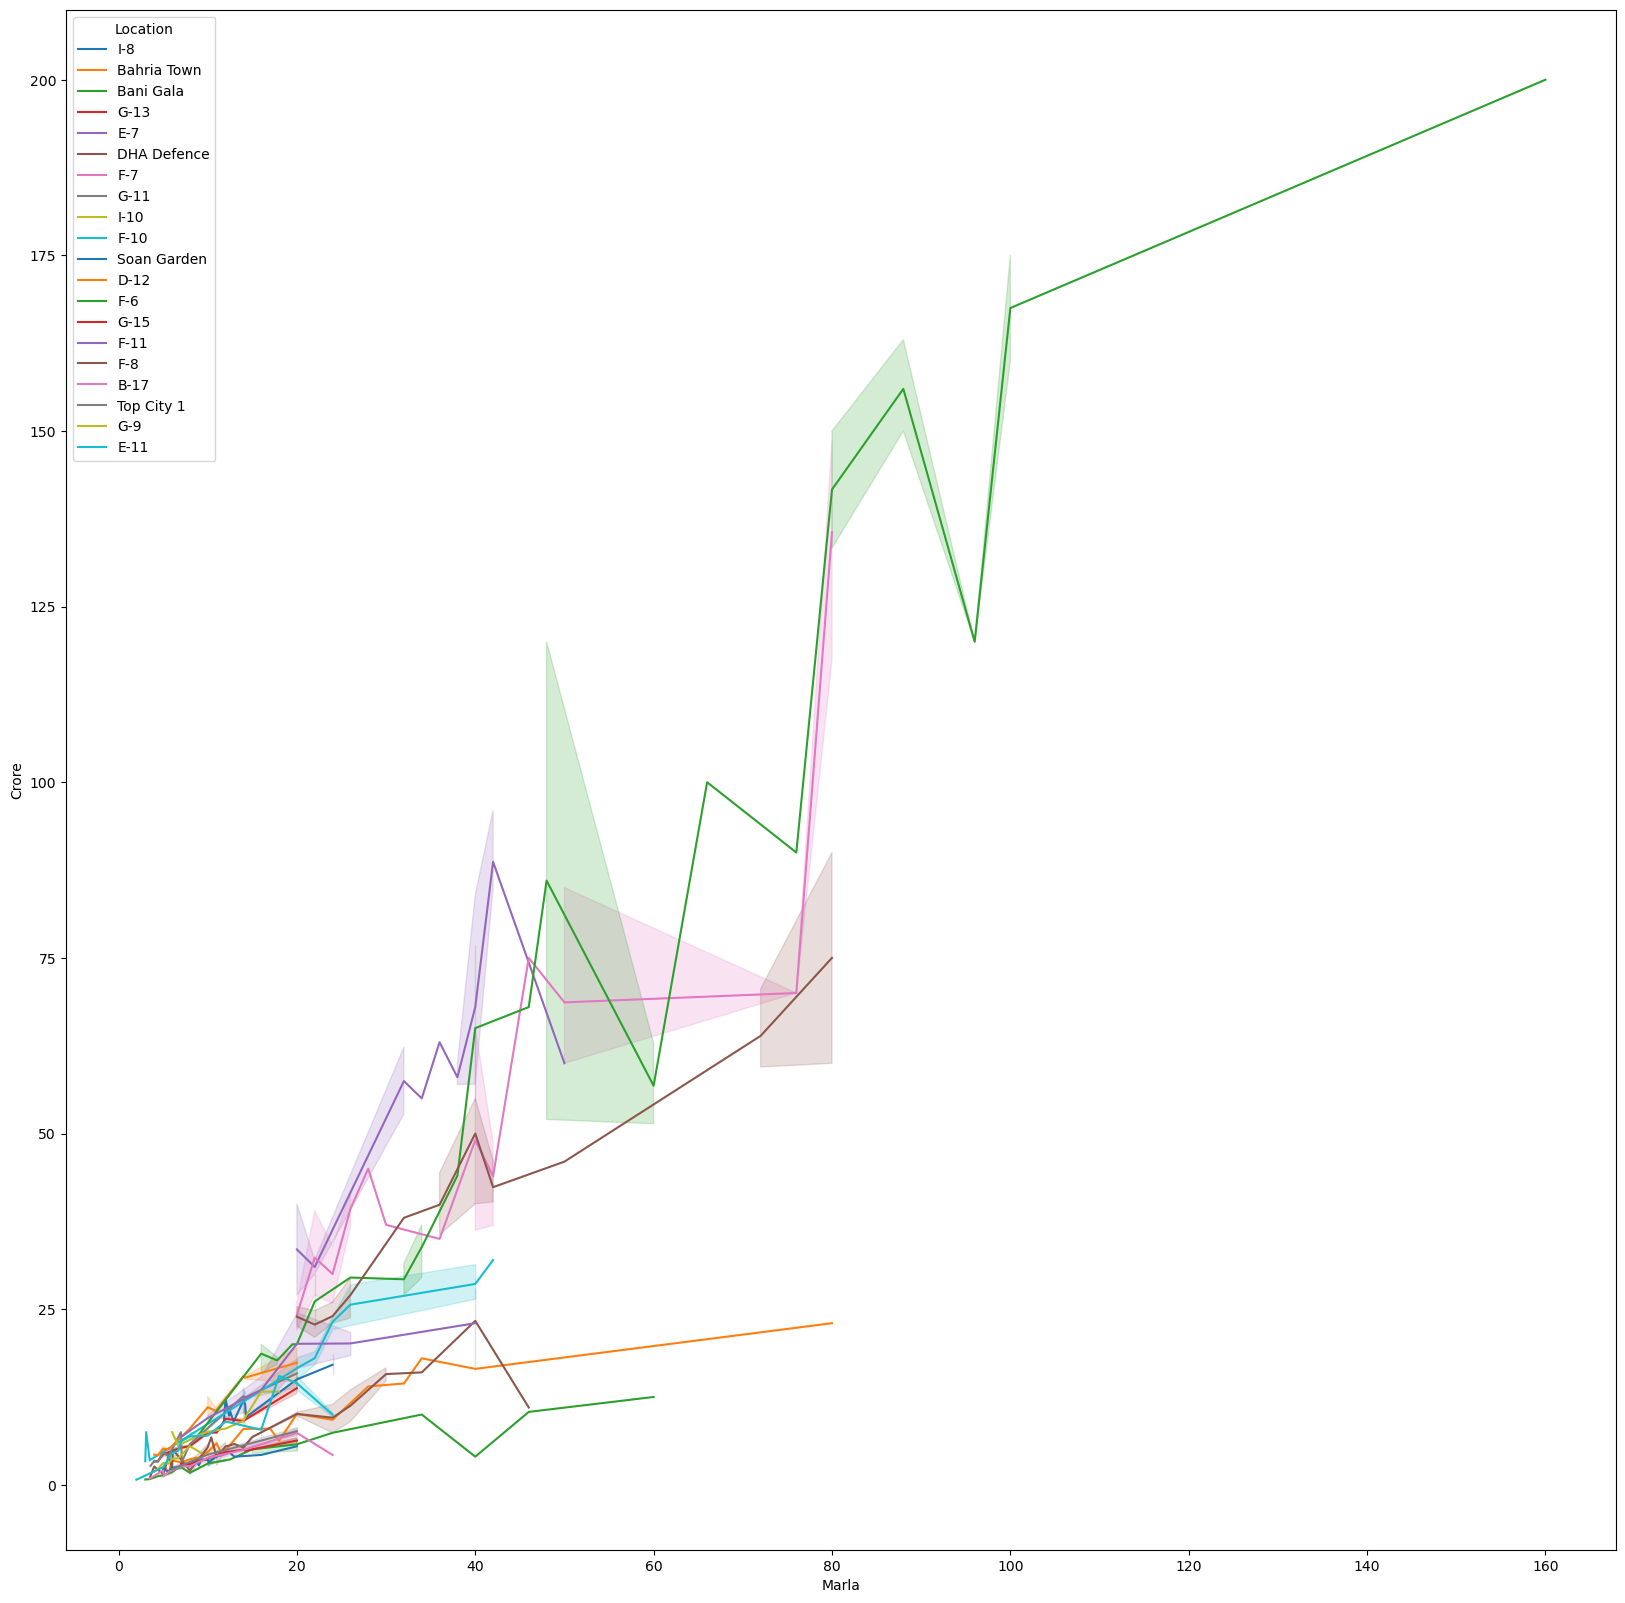

In [20]:
plt.figure(figsize=(20,20))
sns.lineplot(data = df, x = 'Marla', y = 'Crore', hue=Location, palette='tab10')

In [21]:
df['Other Rooms'] = df['Steam Room'] + df['Prayer Rooms'] + df['Dining Room'] + df['Laundry Room'] + df['Drawing Room'] + df['Lounge or Sitting Room'] + df['Powder Room'] + df['Gym'] + df['Kitchens']


In [22]:
df = df.drop(columns=['Dining Room', 'Laundry Room', 'Store Rooms',
       'Kitchens', 'Drawing Room', 'Gym', 'Powder Room', 'Steam Room',
       'No additional rooms', 'Prayer Rooms', 'Lounge or Sitting Room'])

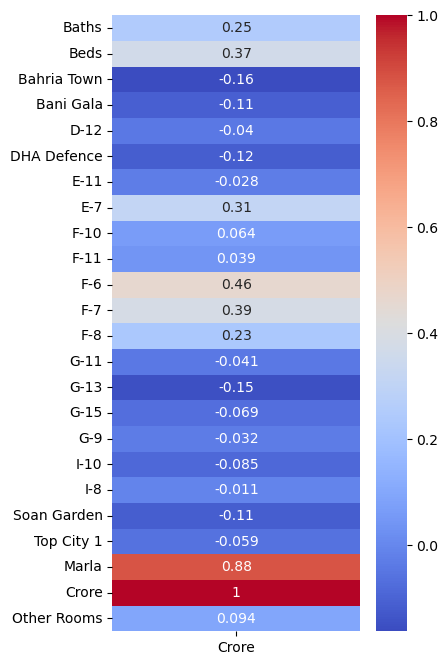

In [23]:
plt.figure(figsize=(4,8))
sns.heatmap(df.corr()[['Crore']], cmap='coolwarm', annot=True)
plt.show()

In [24]:
df.describe()

,Baths,Beds,Bahria Town,Bani Gala,D-12,DHA Defence,E-11,E-7,F-10,F-11,...,G-13,G-15,G-9,I-10,I-8,Soan Garden,Top City 1,Marla,Crore,Other Rooms
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,...,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,5.495030,5.480451,0.129887,0.045063,0.025182,0.210736,0.021206,0.020543,0.027170,0.025845,...,0.166998,0.021869,0.019218,0.028496,0.029821,0.050364,0.019218,16.849238,13.807359,5.766733
std,1.059006,1.487943,0.336291,0.207511,0.156730,0.407966,0.144119,0.141897,0.162633,0.158725,...,0.373098,0.146304,0.137336,0.166439,0.170150,0.218768,0.137336,13.863055,20.905505,3.772360
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.610000,0.000000
25%,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,4.000000,2.000000
50%,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.750000,7.000000
75%,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,13.000000,9.000000
max,10.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,160.000000,200.000000,18.000000


In [25]:
_, ideal_edges = pd.qcut(df['Crore'], q=5, retbins=True)
print("Mathematical 20% Bins:", [round(x, 2) for x in ideal_edges])

Mathematical 20% Bins: [0.61, 3.5, 5.52, 9.19, 15.5, 200.0]


In [26]:
bins = [0, 3.5, 5.5, 9, 15.5, np.inf]
labels = [0, 1, 2, 3, 4]

df['price_category'] = pd.cut(df['Crore'], bins=bins, labels=labels, right=False).astype(int)

### Remove feature imbalance using 2 methods and compare

###### Random shuffle

In [27]:
from sklearn.model_selection import GridSearchCV, train_test_split

traindf, testdf = train_test_split(df, test_size=0.2)

In [28]:
Bahria = traindf[(traindf['Bahria Town'] == 1)]
reshuffle1 = Bahria.sample(70, random_state=42)

DHA = traindf[(traindf['DHA Defence'] == 1)]
reshuffle2 = DHA.sample(70, random_state=42)

G13 = traindf[(traindf['G-13'] == 1)]
reshuffle3 = G13.sample(70, random_state=42)

keep = traindf[~((traindf['Bahria Town'] == 1) | (traindf['DHA Defence'] == 1) | (traindf['G-13'] == 1))]

reshuffled = pd.concat([keep,reshuffle1,reshuffle2,reshuffle3])

###### Clustering

In [29]:
from sklearn.cluster import KMeans

balancing_features = ['Crore', 'Marla']
target_size = 70

kmeans_b = KMeans(n_clusters=target_size, random_state=42, n_init='auto').fit(Bahria[balancing_features])
idx_b = [((Bahria[balancing_features] - center)**2).sum(axis=1).idxmin() for center in kmeans_b.cluster_centers_]
cluster1 = Bahria.loc[idx_b]

kmeans_d = KMeans(n_clusters=target_size, random_state=42, n_init='auto').fit(DHA[balancing_features])
idx_d = [((DHA[balancing_features] - center)**2).sum(axis=1).idxmin() for center in kmeans_d.cluster_centers_]
cluster2 = DHA.loc[idx_d]

kmeans_g = KMeans(n_clusters=target_size, random_state=42, n_init='auto').fit(G13[balancing_features])
idx_g = [((G13[balancing_features] - center)**2).sum(axis=1).idxmin() for center in kmeans_g.cluster_centers_]
cluster3 = G13.loc[idx_g]

clustered = pd.concat([keep, cluster1, cluster2, cluster3])

### Training

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

from xgboost import XGBClassifier

In [31]:
X_train = traindf.drop(columns = ['Crore','price_category'])
y_train = traindf['price_category']

rX_train = reshuffled.drop(columns = ['Crore','price_category'])
ry_train = reshuffled['price_category']

cX_train = clustered.drop(columns = ['Crore','price_category'])
cy_train = clustered['price_category']

X_test = testdf.drop(columns = ['Crore','price_category'])
y_test = testdf['price_category']

In [32]:
pipe = Pipeline([
    ('scale', StandardScaler()), 
    ('model', XGBClassifier(
        learning_rate=0.3,
        max_depth=3,
        min_child_weight=0,
        reg_alpha=0.05,
        reg_lambda=1.5,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
])
pipe1 = Pipeline([
    ('scale', StandardScaler()), 
    ('model', XGBClassifier(
        learning_rate=0.3,
        max_depth=3,
        min_child_weight=0,
        reg_alpha=0.05,
        reg_lambda=1.5,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
])
pipe2 = Pipeline([
    ('scale', StandardScaler()), 
    ('model', XGBClassifier(
        learning_rate=0.3,
        max_depth=3,
        min_child_weight=0,
        reg_alpha=0.05,
        reg_lambda=1.5,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
])


In [33]:
pipe.fit(X_train,y_train)
pipe1.fit(rX_train,ry_train)
pipe2.fit(cX_train,cy_train)

Pipeline(steps=[('scale', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.3,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=0,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=None,
                               n_jobs=None, num_parallel_tree=None,
                               objective='multi:softprob', ...))])

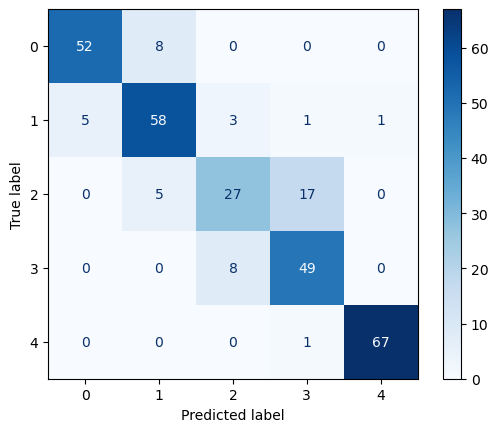

In [34]:
pred = pipe.predict(X_test)
pred1 = pipe1.predict(X_test)
pred2 = pipe2.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(cmap=plt.cm.Blues)

In [35]:
print('Normal')
print(accuracy_score(y_test,pred))
print(f1_score(y_test,pred, average='weighted'))
print(recall_score(y_test,pred, average='weighted'))

print('Random')
print(accuracy_score(y_test,pred1))
print(f1_score(y_test,pred1, average='weighted'))
print(recall_score(y_test,pred1, average='weighted'))

print('Clustered')
print(accuracy_score(y_test,pred2))
print(f1_score(y_test,pred2, average='weighted'))
print(recall_score(y_test,pred2, average='weighted'))

Normal
0.8377483443708609
0.8350441320385117
0.8377483443708609
Random
0.8013245033112583
0.7996532293370942
0.8013245033112583
Clustered
0.804635761589404
0.8015433384941282
0.804635761589404


### Observation:
- All metrics score is typically between 0.76-0.84
- No one model performs noticably better than another (+- 0.03)
- Often Normal performs better

In [36]:
param_grid = {
    'scale': [StandardScaler(), RobustScaler(), None],
    'model__max_depth': [2, 3, 4],

    'model__learning_rate': [0.3, 0.2, 0.25],

    'model__min_child_weight': [0, 1, 2],

    'model__reg_alpha': [0, 0.05, 0.1],
    'model__reg_lambda': [1.5, 2, 2.5, 1]
}

from sklearn.model_selection import RandomizedSearchCV

grid = RandomizedSearchCV(
    estimator=pipe, 
    param_distributions=param_grid, 
    n_iter=30,                  # Randomly selects and checks 30 combinations
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

#grid.fit(X_train,y_train)
#print(grid.best_params_)

In [37]:
import pickle

with open("model.pkl",'wb') as f:
    pickle.dump(pipe, f)

### API testing

In [38]:
from pydantic import BaseModel, Field, computed_field, field_validator
from typing import Literal, Annotated

cities = ['B-17', 'Bahria Town', 'Bani Gala', 'D-12', 'DHA Defence',
       'E-11', 'E-7', 'F-10', 'F-11', 'F-6', 'F-7', 'F-8', 'G-11', 'G-13',
       'G-15', 'G-9', 'I-10', 'I-8', 'Soan Garden', 'Top City 1']

params = ['Baths', 'Beds', 'Bahria Town', 'Bani Gala', 'D-12', 'DHA Defence',
       'E-11', 'E-7', 'F-10', 'F-11', 'F-6', 'F-7', 'F-8', 'G-11', 'G-13',
       'G-15', 'G-9', 'I-10', 'I-8', 'Soan Garden', 'Top City 1', 'Marla',
       'Other Rooms']

class UserInput(BaseModel):
    baths : Annotated[int, Field(...,gt = 0, le=10, description = 'Number of baths in the house')]
    beds : Annotated[int, Field(...,gt = 0, le=11, description = 'Number of beds in the house')]
    marla : Annotated[float, Field(...,gt = 2, le=160, description = 'Number of beds in the house')]
    rooms : Annotated[int, Field(...,ge = 0, le=11, description = 'Number of rooms in the house')]
    location : Annotated[Literal[tuple(cities)], Field(..., description = 'Location of the house')]

labels = {
    0: "Less than 3.5 Crore",
    1: "3.5 - 5.5 Crore",
    2: "5.5 - 9 Crore",
    3: "9 - 15.5 Crore",
    4: "More than 15.5 Crore"
}

In [39]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse

import nest_asyncio
import uvicorn

nest_asyncio.apply()

app = FastAPI()

pd.set_option('display.max_column', None)

with open('model.pkl','rb') as f:
    model = pickle.load(f)

In [40]:
@app.get("/")
async def home():
    return {"Islamabad Home" : "Price Prediction"}

@app.post('/predict')
async def predict_price(data: UserInput):

    features = np.concatenate([np.array([data.baths, data.beds]), np.zeros(19), np.array([data.marla, data.rooms])])
    X = pd.DataFrame(features.reshape(1, -1), columns=params)

    if data.location != 'B-17':
        X[data.location] = 1
    #print(X)
    
    y = model.predict(X)
    print(y)
    prediction_index = int(y[0])

    # .get() prevents crashes by offering a fallback if the key doesn't exist
    predicted_label = labels.get(prediction_index, f"Unknown key received from model: {prediction_index}")

    return JSONResponse(status_code=200, content={'predicted_price': predicted_label})

In [41]:
import asyncio

if __name__ == "__main__":
    config = uvicorn.Config(app, host="127.0.0.1", port=8000)
    server = uvicorn.Server(config)
    
    # Grab the active loop that Jupyter/nest_asyncio is using
    loop = asyncio.get_event_loop()
    
    # Run the server inside the existing loop instead of creating a new one
    loop.create_task(server.serve())

INFO:     Started server process [22953]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
